$\color{#1E90FF}{\text{Anusha Sundar, 8/3/2026}}$

# **Context**
AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers.

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.

# **Objective**
Identify different segments in the existing customer base, taking into account their spending patterns as well as past interactions with the bank.

# **Data Description**
Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.



*   Sl_no - Customer Serial Number

*   Customer Key - Customer identification


*   Avg_Credit_Limit - Average credit limit (currency is not specified, you can make an assumption around this)
*   Total_Credit_Cards - Total number of credit cards


*   Total_Credit_Cards - Total number of credit cards
*   Total_visits_bank - Total bank visits



*   Total_visits_online - Total online visits

*   Total_calls_made - Total calls made

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd


# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style='darkgrid')

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# To scale the data using z-score
from sklearn.preprocessing import StandardScaler

# To compute distances
from scipy.spatial.distance import cdist, pdist


# To perform K-Means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# To import K-Medoids
# from sklearn_extra.cluster import KMedoids


# To import DBSCAN and Gaussian Mixture
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# To perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv ('/content/drive/MyDrive/Colab Notebooks/Credit Card Customer Data (2).csv')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [ ]:
df.shape

(660, 7)

In [ ]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [ ]:
df.duplicated().sum()

0

$\color{#1E90FF}{\text{Since customer keys tend to be assigned in sequential order, let's take our sweet time and start our preliminary EDA inquiry by segmenting by customer key ranges.}}$


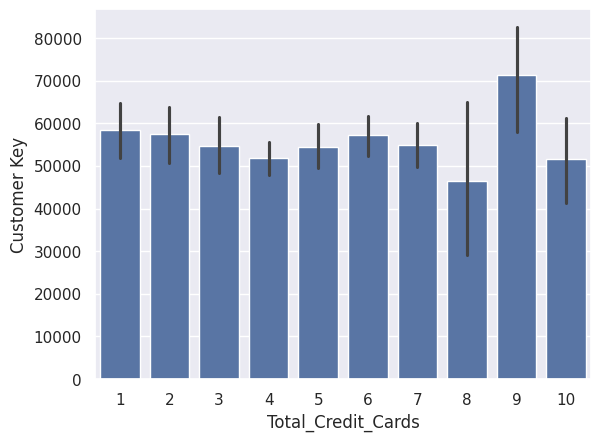

In [ ]:
#it seems, initially, that customers with IDs higher than 4000 typically have more total credit cards,
#but the lengthened black error lines at "8 and 9 credit cards" imply that there is great variance in these groups with these many credit cards and
#this graph is not reliable for interpretation of customer keys' possible influences

sns.barplot(data=df, x='Total_Credit_Cards', y = 'Customer Key')
plt.show()

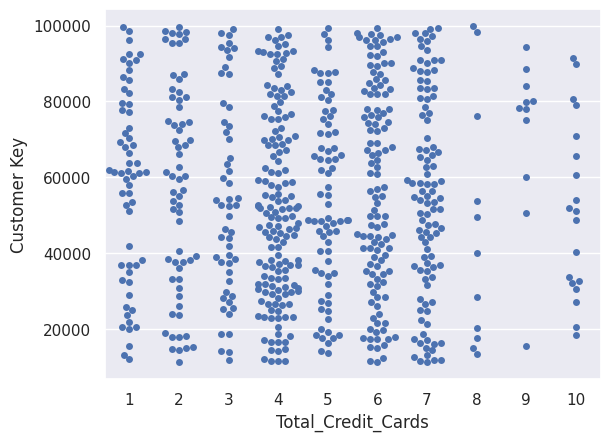

In [ ]:
sns.swarmplot(data=df, x='Total_Credit_Cards', y='Customer Key')

plt.show()

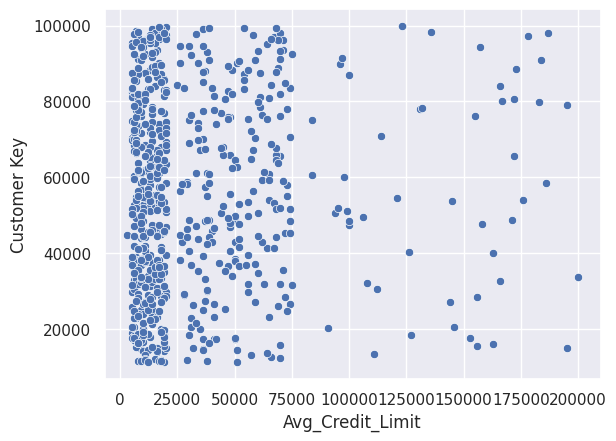

In [ ]:
sns.scatterplot(data=df, x='Avg_Credit_Limit', y = 'Customer Key')
plt.show()

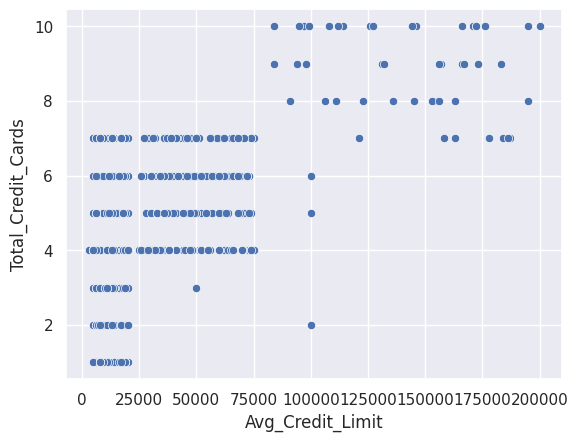

In [ ]:
sns.scatterplot(data=df, x='Avg_Credit_Limit', y = 'Total_Credit_Cards')
figsize = (100, 100)
plt.show()

$\color{#1E90FF}{\text{There is a stronger, directly proportional relationship visible between Total Credit Cards and Avg Credit Limit than between either of those and Customer Keys. However, let's finish off exploring our initial guess regarding possibly sequentially assigned customer keys by segmenting them.}}$

In [ ]:
conditionzero = (df['Customer Key'] > 80000)
countzero = df[conditionzero].shape[0]

print(f"Number of rows greater than 80000: {countzero}")

Number of rows greater than 80000: 146


In [ ]:
condition = (df['Customer Key'] > 60000) & (df['Customer Key'] < 80000)
counttwo = df[condition].shape[0]

print(f"Number of rows greater than 60000 and less than 80000: {counttwo}")

Number of rows greater than 60000 and less than 80000: 139


In [ ]:
conditionone = (df['Customer Key'] > 40000) & (df['Customer Key'] < 60000)
countthree = df[conditionone].shape[0]

print(f"Number of rows greater than 40000 and less than 60000: {countthree}")

Number of rows greater than 40000 and less than 60000: 157


In [ ]:
conditiontwo = (df['Customer Key'] > 20000) & (df['Customer Key'] < 40000)
countfour = df[conditiontwo].shape[0]

print(f"Number of rows greater than 20000 and less than 40000: {countfour}")

Number of rows greater than 20000 and less than 40000: 148


In [ ]:
conditionthree = (df['Customer Key'] < 20000)
countfive = df[conditionthree].shape[0]

print(f"Number of rows less than 20000: {countfive}")

Number of rows less than 20000: 70


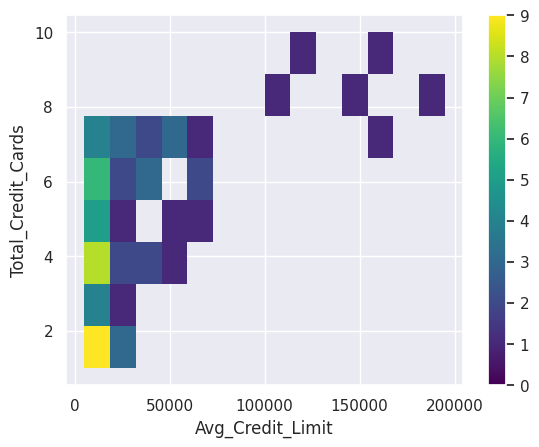

In [ ]:
sns.histplot(data=df[conditionthree], x='Avg_Credit_Limit', y='Total_Credit_Cards', kde=True, cbar=True, cmap='viridis')
plt.show()

**smallest group (count: 70) with Customer ID [0, 2000] | they seem to have trend of low total credit cards and low avg credit limit**

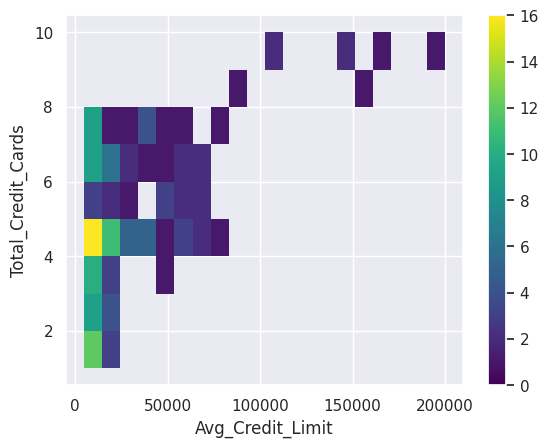

In [ ]:
sns.histplot(data=df[conditiontwo], x='Avg_Credit_Limit', y='Total_Credit_Cards', kde=True, cbar=True, cmap='viridis')
plt.show()

**(count: 148) with Customer ID [2000, 4000] | increased total number of credit cards, still low average credit limit**

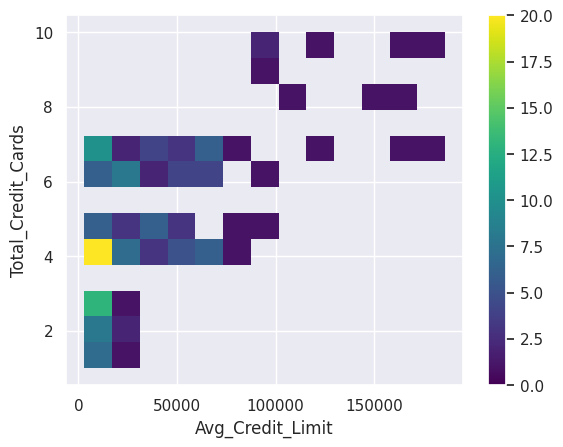

In [ ]:
sns.histplot(data=df[conditionone], x='Avg_Credit_Limit', y='Total_Credit_Cards', kde=True, cbar=True, cmap='viridis')
plt.show()

**(count: 157) with Customer ID [4000, 6000] | more scattered than previous range with similar trend of increased total number of credit cards, mostly low, some medium average credit limit**

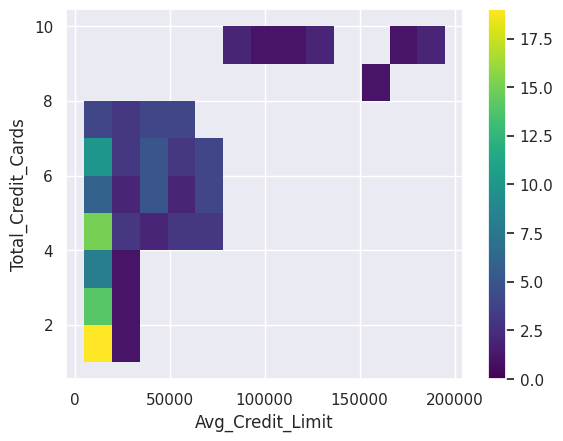

In [ ]:
sns.histplot(data=df[condition], x='Avg_Credit_Limit', y='Total_Credit_Cards', kde=True, cbar=True, cmap='viridis')
plt.show()

**(count: 139) with Customer ID [6000, 8000] | low number of total credit cards, low average credit limit**

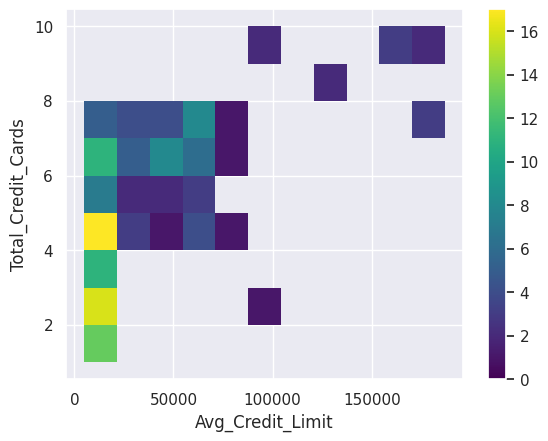

In [ ]:
sns.histplot(data=df[conditionzero], x='Avg_Credit_Limit', y='Total_Credit_Cards', kde=True, cbar=True, cmap='viridis')
plt.show()

**(count: 146) with Customer ID [8000+] | higher total number of credit cards with rather low average credit limit**


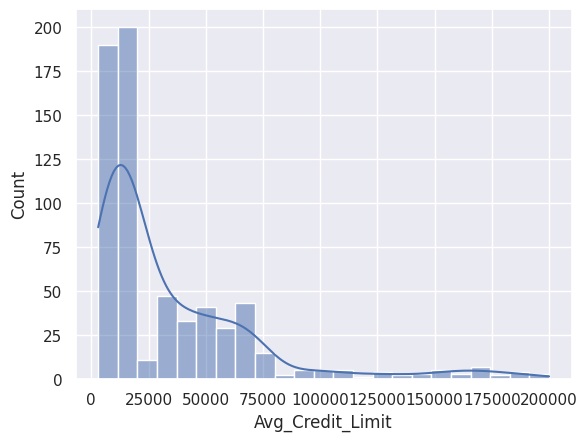

In [ ]:
#far fewer customers with high average credit limits

sns.histplot(data=df, x='Avg_Credit_Limit', kde=True)
plt.show()

<Figure size 15000x10000 with 0 Axes>

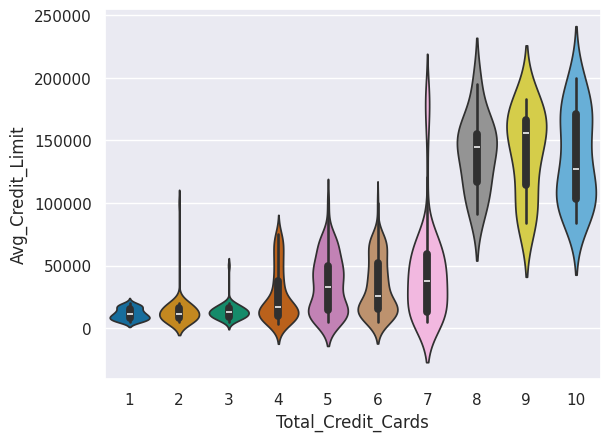

<Figure size 15000x10000 with 0 Axes>

In [ ]:
#greater number of credit cards strongly correlated to higher average credit limits
 #(more responsible spending linked to higher eligibility for credit card acquisition/expansion)

sns.violinplot(data=df, x='Total_Credit_Cards', y='Avg_Credit_Limit', palette='colorblind')
plt.figure(figsize=(150,100))


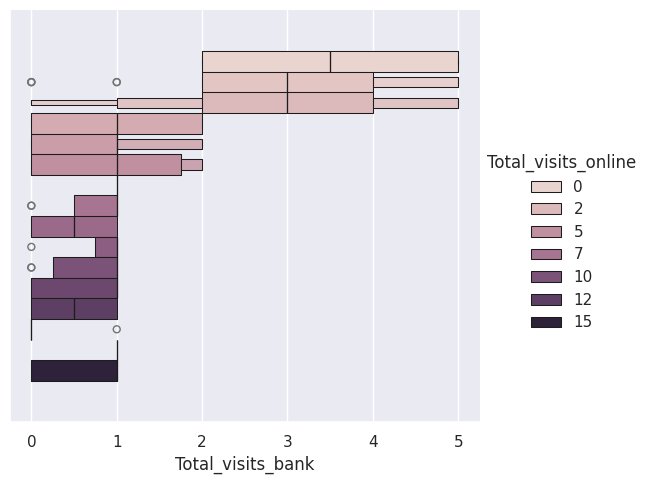

In [ ]:
#inverse relationship between visits to bank vs. online
#high in-person bank visitors rarely use online services
#high online service users rarely visit the bank in-person


sns.catplot(data=df, x='Total_visits_bank', kind='boxen', hue='Total_visits_online')
plt.show()

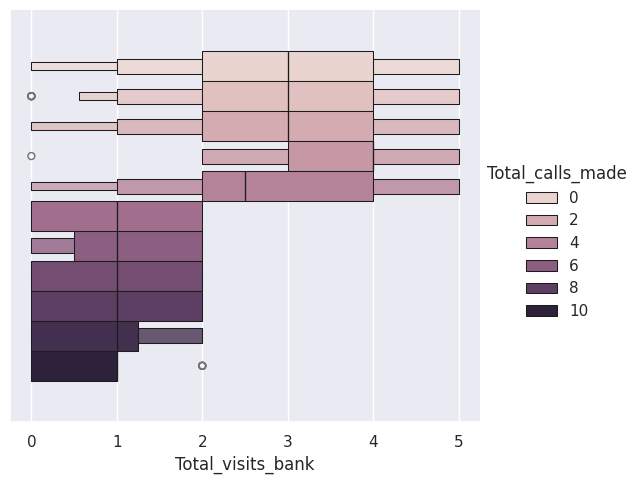

In [ ]:
#inverse relationship between visits to bank vs. phone calls made
#high in-person bank visitors rarely use call in
#high callers rarely visit the bank in-person


sns.catplot(data=df, x='Total_visits_bank', kind='boxen', hue='Total_calls_made')
plt.show()

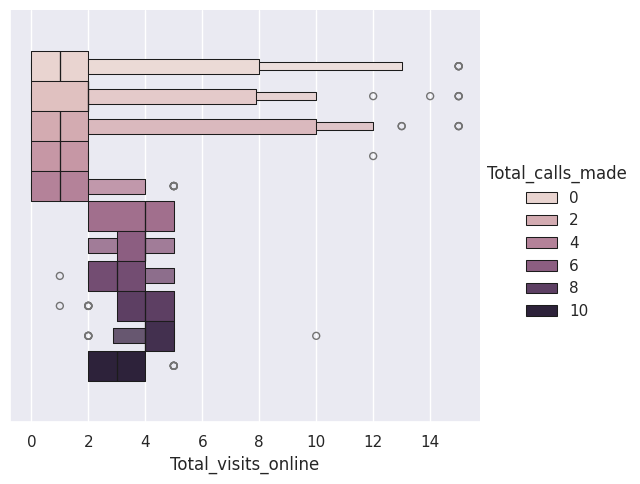

In [ ]:
#some customers who call in frequently rarely use online services
#some customers who use online services frequently rarely call in

sns.catplot(data=df, x='Total_visits_online', kind='boxen', hue='Total_calls_made')
plt.show()

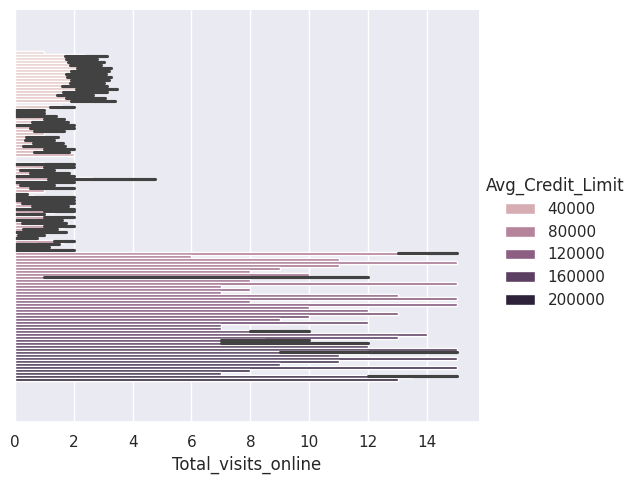

In [ ]:
sns.catplot(data=df, x='Total_visits_online', kind='bar', hue='Avg_Credit_Limit')
plt.show()

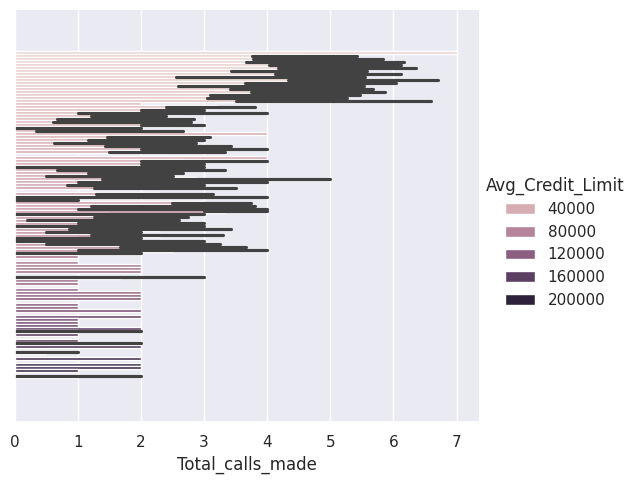

In [ ]:
sns.catplot(data=df, x='Total_calls_made', kind='bar', hue='Avg_Credit_Limit')
plt.show()

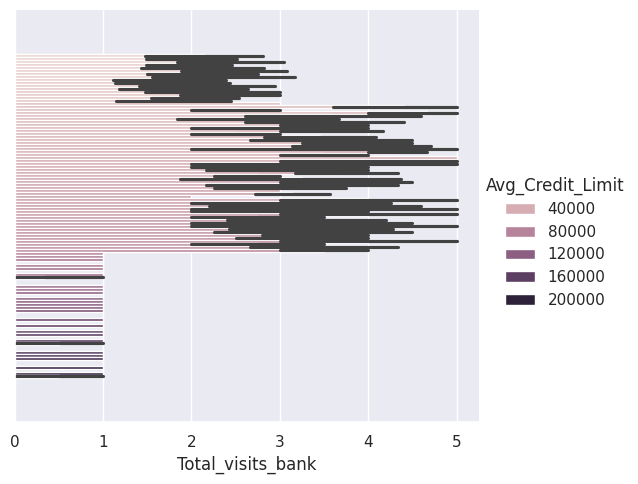

In [ ]:
#customers with lower ranged average credit limits visit the bank, in total, more frequently than customers with highest ranges of average credit limits

sns.catplot(data=df, x='Total_visits_bank', kind='bar', hue='Avg_Credit_Limit')
plt.show()

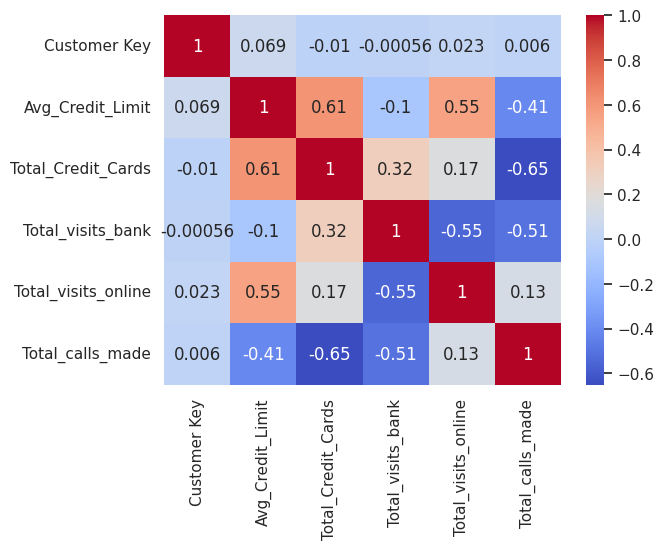

In [ ]:
sns.heatmap(data=df[['Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank','Total_visits_online','Total_calls_made']].corr(), annot=True, cmap="coolwarm")
plt.show()


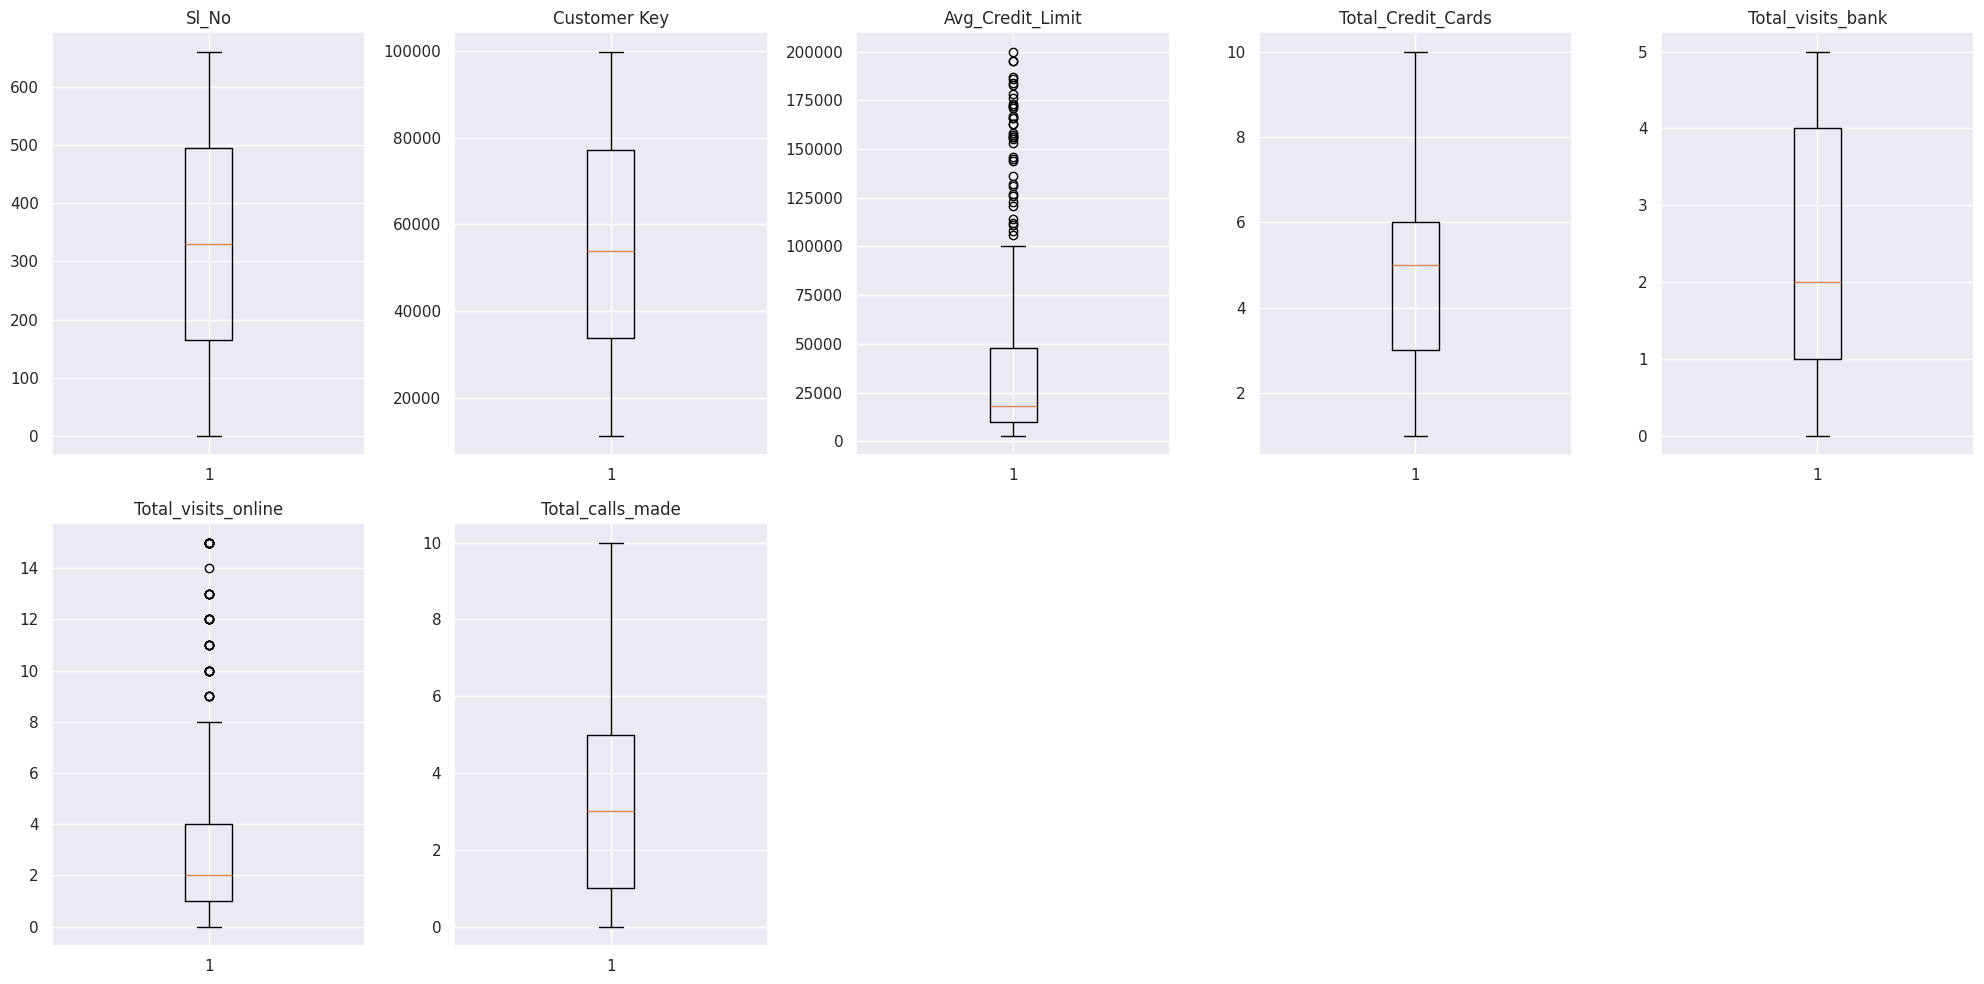

In [ ]:
plt.figure(figsize = (20, 10))

numeric_columns = df.select_dtypes(include = np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):

    plt.subplot(2, 5, i + 1)

    plt.boxplot(df[variable], whis = 1.5)

    plt.tight_layout()

    plt.title(variable)

plt.show()

**o u t l i e r s**

**Avg_Credit_Limit:** a small group of customers with exceptionally high credit limits compared to the typical bank customer

**Total_visits_online:** a subset of customers who visit the online platform far more frequently than average

In [ ]:
# Scaling for distance-based clustering
scaler = StandardScaler()
subset = df.iloc[:, 3:].copy()
subset_scaled = scaler.fit_transform(subset)

subset_scaled_df = pd.DataFrame(subset_scaled, columns = subset.columns)

In [ ]:
# Importing PCA
from sklearn.decomposition import PCA

# Defining the number of principal components to generate
n = subset.shape[1]                                                 # Storing the number of variables in the data

pca = PCA(n_components = n, random_state = 1)                       # Storing PCA function with n components

data_pca = pd.DataFrame(pca.fit_transform(subset_scaled_df ))       # Applying PCA on scaled data

# The percentage of variance explained by each principal component is stored
exp_var = (pca.explained_variance_ratio_)

In [ ]:
k_means_df = data_pca.copy()

Number of Clusters: 1 	Average Distortion: 1.8259548346750432
Number of Clusters: 2 	Average Distortion: 1.2833281046057636
Number of Clusters: 3 	Average Distortion: 1.0289227488774144
Number of Clusters: 4 	Average Distortion: 0.9714285314815827
Number of Clusters: 5 	Average Distortion: 0.8587064691923961
Number of Clusters: 6 	Average Distortion: 0.8342042400071832
Number of Clusters: 7 	Average Distortion: 0.7920824303044859
Number of Clusters: 8 	Average Distortion: 0.7724640459397679
Number of Clusters: 9 	Average Distortion: 0.7555382064864556
Number of Clusters: 10 	Average Distortion: 0.71758183423358
Number of Clusters: 11 	Average Distortion: 0.6975703024609863
Number of Clusters: 12 	Average Distortion: 0.6736179238198625
Number of Clusters: 13 	Average Distortion: 0.6499083113228399
Number of Clusters: 14 	Average Distortion: 0.6489413215441231


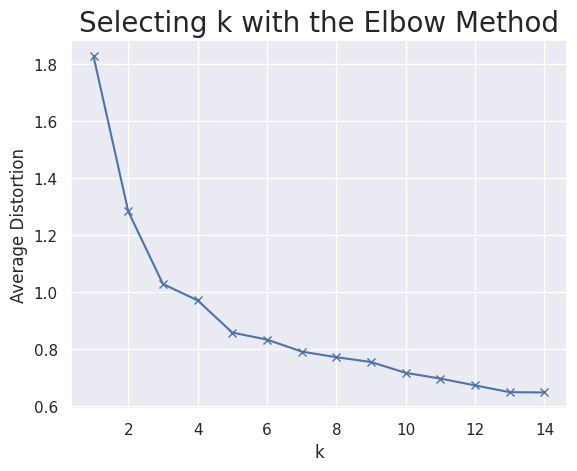

In [ ]:
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters = k, random_state = 1, n_init = "auto")
    model.fit(data_pca)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis = 1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize = 20)
plt.show()

**k=5**

In [ ]:
kmeans = KMeans(n_clusters = 5, random_state = 1, n_init = "auto")
kmeans.fit(k_means_df)

KMeans(n_clusters=5, random_state=1)

In [ ]:
print("WGSS (Inertia):", kmeans.inertia_)


WGSS (Inertia): 527.0913206850335


In [ ]:
# Creating a copy of the original data
df1 = df.copy()

# Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [ ]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only = True)

In [ ]:
# Creating the "count_in_each_segment" feature in K-Means cluster profile

km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Avg_Credit_Limit"].count().values
)

In [ ]:
km_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KM_segments,,,,,,,,
0,421.224490,53997.377551,35785.714286,5.561224,2.500000,0.959184,2.081633,196
1,122.414414,56171.000000,12414.414414,2.207207,0.918919,3.675676,8.549550,111
2,110.610619,54457.150442,12761.061947,2.592920,0.938053,3.424779,5.185841,113
3,415.363158,55714.684211,31226.315789,5.478947,4.515789,1.010526,1.936842,190
4,611.280000,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50


In [ ]:
df1.groupby(["KM_segments", "Total_visits_online"])['Total_Credit_Cards'].count()

KM_segments  Total_visits_online
0            0                      72
             1                      61
             2                      62
             3                       1
1            1                       1
             2                      23
             3                      23
             4                      33
             5                      30
             10                      1
2            1                       3
             2                      30
             3                      20
             4                      36
             5                      24
3            0                      72
             1                      44
             2                      74
4            6                       1
             7                       7
             8                       6
             9                       4
             10                      5
             11                      5
             12                      6
             13                      5
             14                      1
             15                     10
Name: Total_Credit_Cards, dtype: int64

In [ ]:
df1.groupby(["KM_segments", "Total_visits_online"])['Avg_Credit_Limit'].count()

KM_segments  Total_visits_online
0            0                      72
             1                      61
             2                      62
             3                       1
1            1                       1
             2                      23
             3                      23
             4                      33
             5                      30
             10                      1
2            1                       3
             2                      30
             3                      20
             4                      36
             5                      24
3            0                      72
             1                      44
             2                      74
4            6                       1
             7                       7
             8                       6
             9                       4
             10                      5
             11                      5
             12                      6
             13                      5
             14                      1
             15                     10
Name: Avg_Credit_Limit, dtype: int64

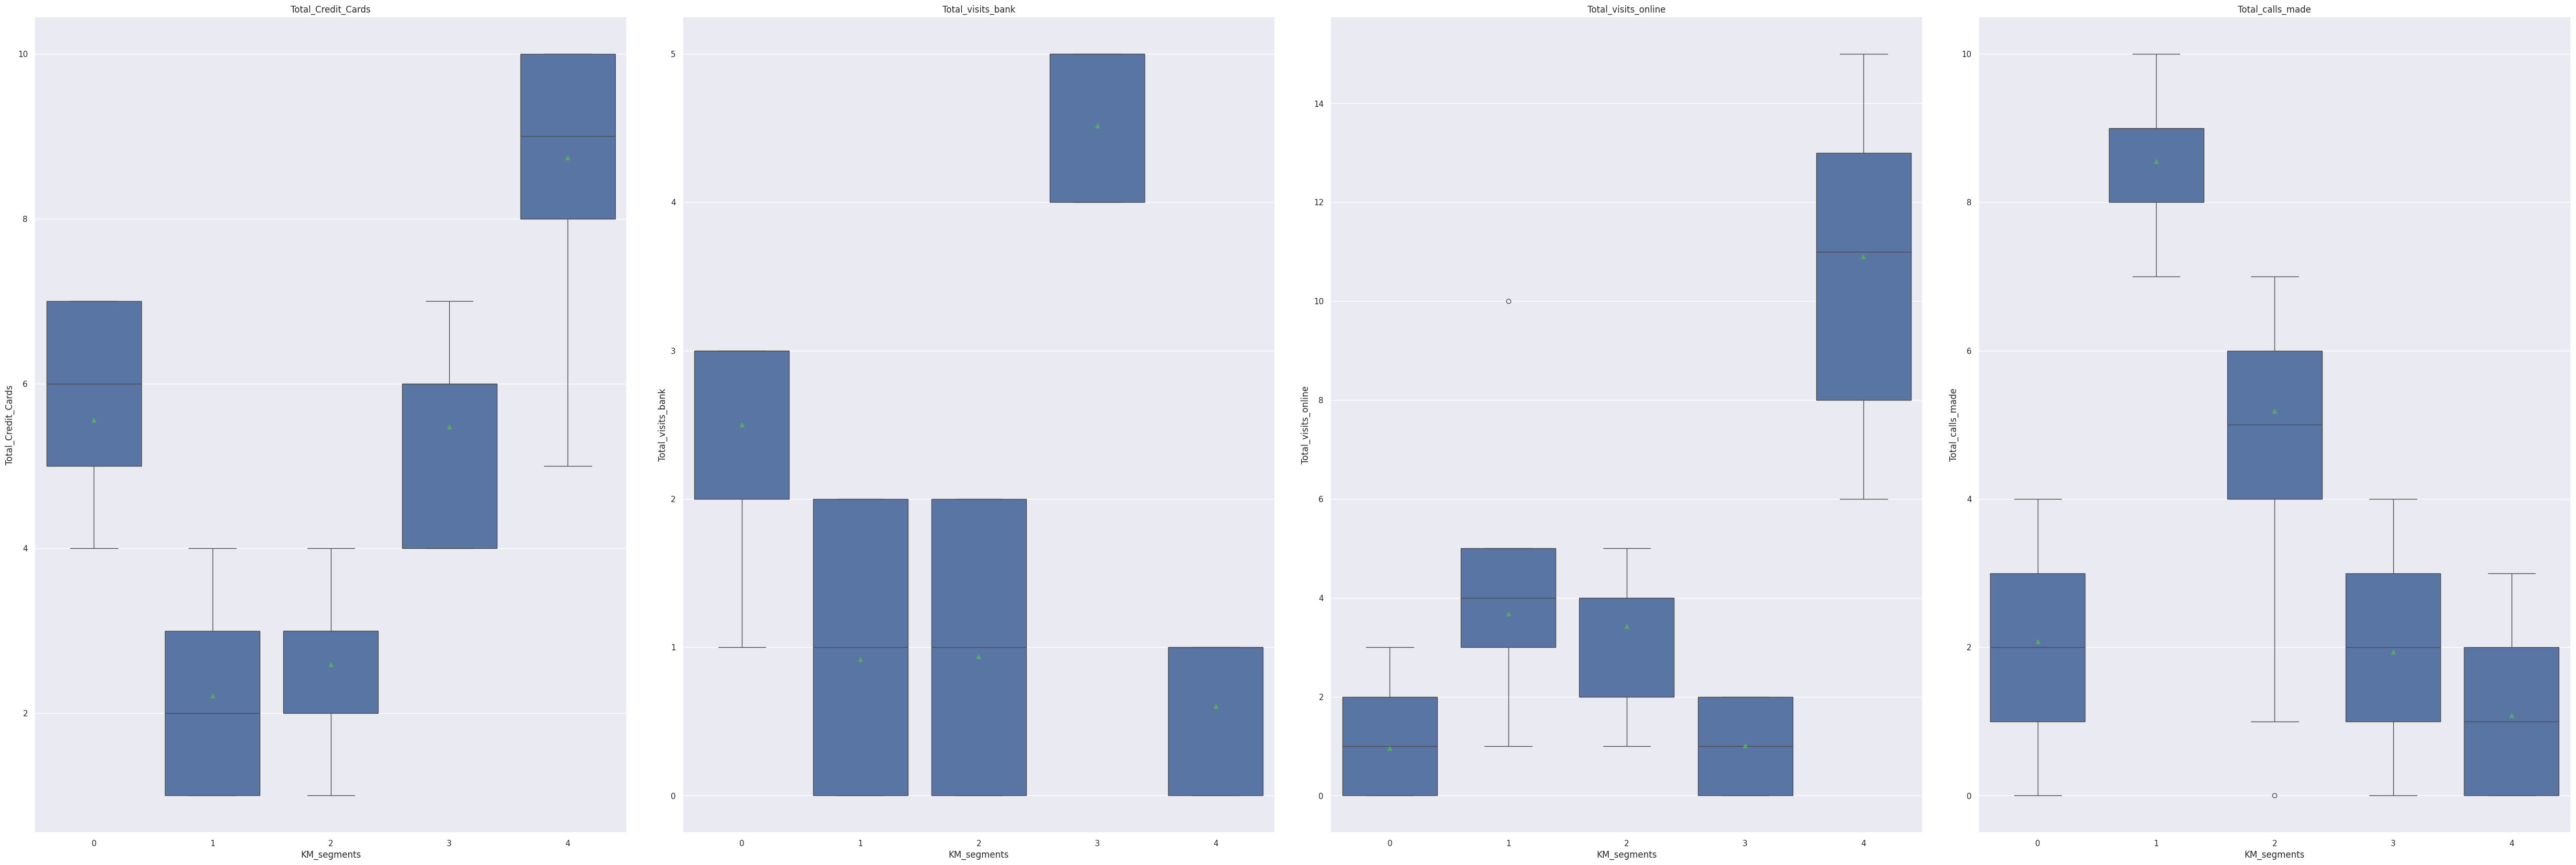

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(50, 50))
axes_flat = axes.flatten() # Flatten the 2D array of axes into a 1D array

# Define the columns that should be plotted
# These are the columns from index 3 onwards in df1, excluding 'KM_segments'
columns_to_plot = df1.columns[3:-1]

# Iterate through the columns to plot and assign each to a subplot
for i, col_name in enumerate(columns_to_plot):
    if i < len(axes_flat):
        sns.boxplot(
            ax=axes_flat[i],
            data=df1,
            y=col_name,
            x="KM_segments",
            showmeans=True
        )
        axes_flat[i].set_title(col_name) # Add a title for clarity
    else:
        break

# Hide any remaining unused subplots
for j in range(len(columns_to_plot), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.tight_layout(pad=3.0)
plt.show()

In [ ]:
cluster_summary = df1.groupby('KM_segments').mean()
print(cluster_summary)

                  Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
KM_segments                                                                   
0            421.224490  53997.377551      35785.714286            5.561224   
1            122.414414  56171.000000      12414.414414            2.207207   
2            110.610619  54457.150442      12761.061947            2.592920   
3            415.363158  55714.684211      31226.315789            5.478947   
4            611.280000  56708.760000     141040.000000            8.740000   

             Total_visits_bank  Total_visits_online  Total_calls_made  
KM_segments                                                            
0                     2.500000             0.959184          2.081633  
1                     0.918919             3.675676          8.549550  
2                     0.938053             3.424779          5.185841  
3                     4.515789             1.010526          1.936842  
4             

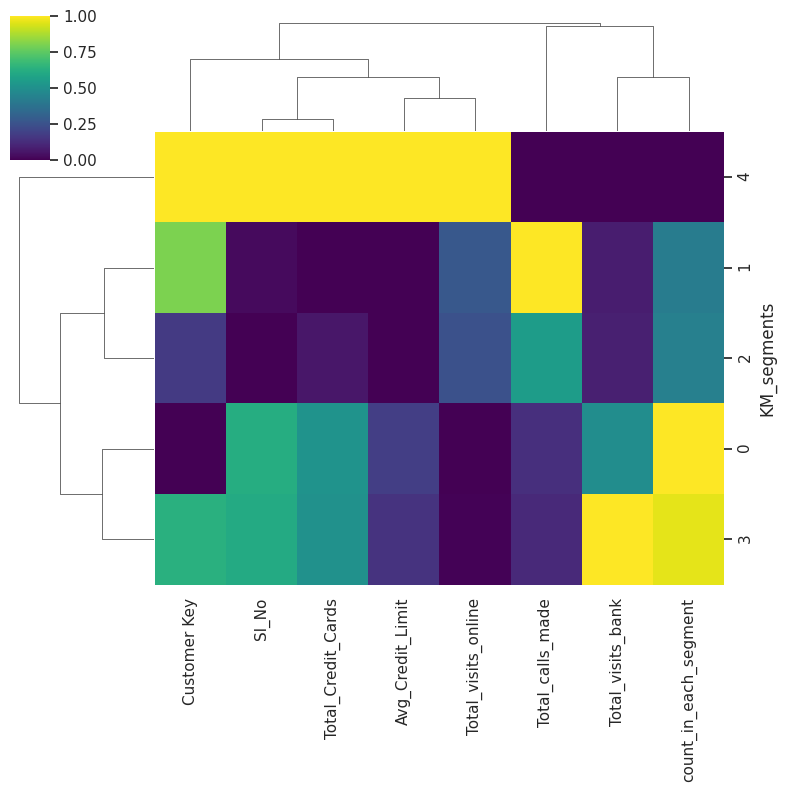

In [ ]:
sns.clustermap(
    km_cluster_profile,
    metric="euclidean",
    method="average",
    cmap="viridis",
    standard_scale=1,  # Normalizes data across rows (0 to 1) to make patterns clear
    figsize=(8, 8),
)

# Display the plot
plt.show()

**Cluster 4 is underrepresented / clusters are uneven.**

**K-Medioids**

In [ ]:
!pip uninstall -y numpy scikit-learn-extra
!pip install "numpy<2"
!pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_

  Using cached scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl


In [ ]:
k_med_df = data_pca.copy()

In [ ]:
kmed = KMedoids(n_clusters = 5, random_state = 1) # Create K-Medoids with nclusters = 5
kmed.fit(k_med_df)

KMedoids(n_clusters=5, random_state=1)

In [ ]:
# Creating a copy of the original data
df2 = df.copy()

# Add K-Medoids cluster labels to K-Medoids data
k_med_df["KMed_segments"] = kmed.labels_
# Add K-Medoids cluster labels to the whole data
df2["KMed_segments"] =  kmed.labels_

In [ ]:
kmed_cluster_profile = df2.groupby("KMed_segments").mean(numeric_only = True)

In [ ]:
df2.groupby(["KMed_segments", "Total_Credit_Cards"])['Avg_Credit_Limit'].count()

KMed_segments  Total_Credit_Cards
0              5                      5
               6                     25
               7                     36
               8                     11
               9                     11
               10                    19
1              1                      2
               2                      2
               3                      1
               4                     70
               5                     18
2              5                     21
               6                     45
               7                     44
3              4                     35
               5                     29
               6                     46
               7                     21
4              1                     57
               2                     62
               3                     52
               4                     46
               5                      1
               6                      1
Name: Avg_Credit_Limit, dtype: int64

In [ ]:
kmed_cluster_profile["count_in_each_segment"] = (
    df2.groupby("KMed_segments")["Total_visits_online"].count().values
)

kmed_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
KMed_segments,,,,,,,,
0,502.728972,56756.018692,84242.990654,7.514019,1.579439,5.485981,2.364486,107
1,409.505376,50819.182796,34752.688172,4.075269,2.806452,1.247312,2.150538,93
2,429.690909,56146.609091,34754.545455,6.209091,3.063636,0.836364,1.054545,110
3,408.305344,56034.167939,29801.526718,5.404580,4.748092,0.931298,2.114504,131
4,116.438356,55149.187215,12995.433790,2.429224,0.899543,3.666667,6.936073,219


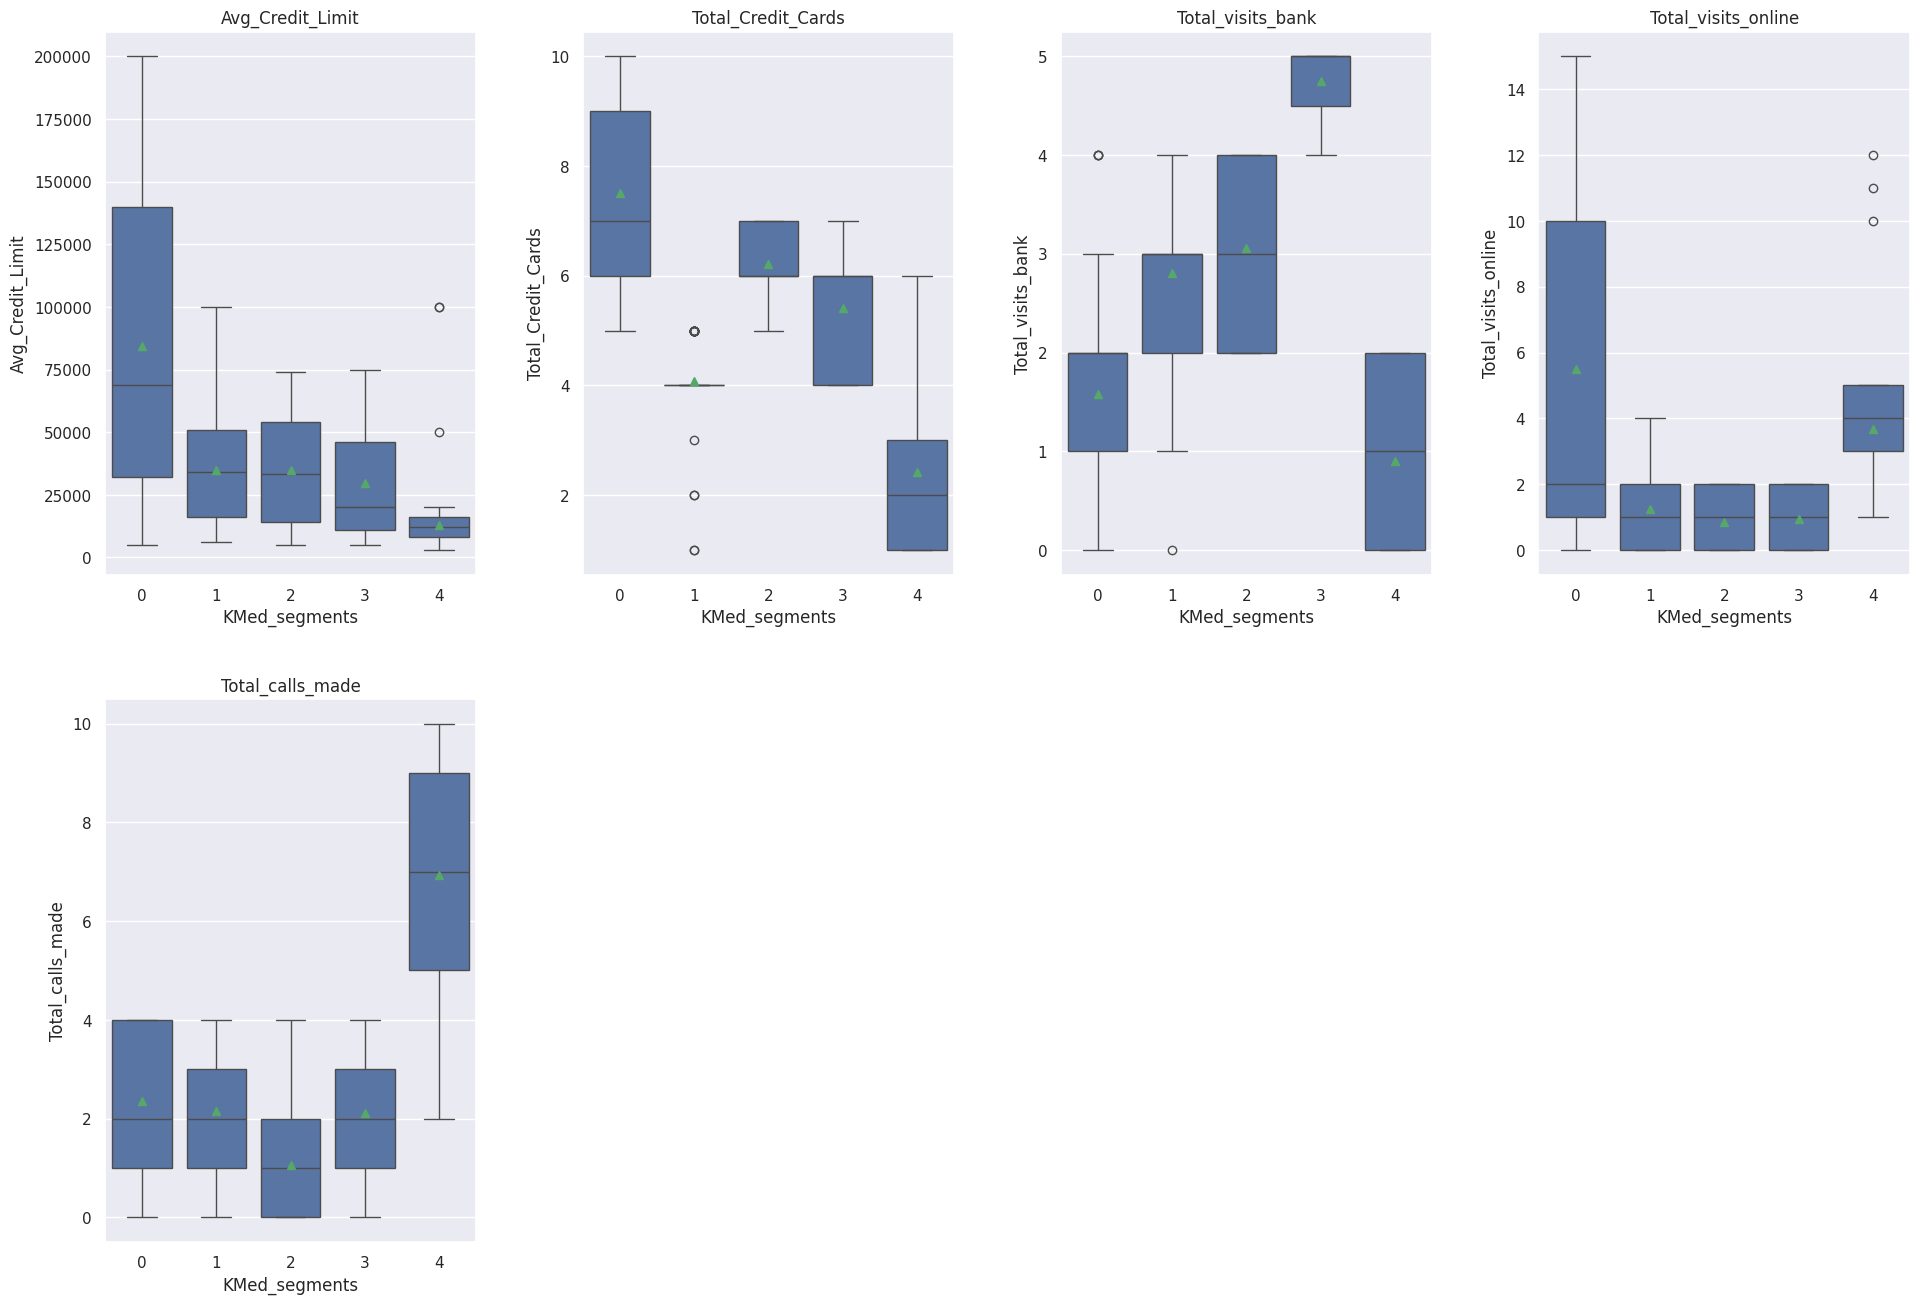

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 20))
axes_flat = axes.flatten() # Flatten the 2D array of axes into a 1D array

columns_to_plot = df2.columns[2:7]

# Iterate through the columns to plot and assign each to a subplot
for i, col_name in enumerate(columns_to_plot):
    if i < len(axes_flat): # Ensure we don't exceed the number of subplots
        sns.boxplot(
            ax=axes_flat[i],
            data=df2,
            y=col_name,
            x="KMed_segments",
            showmeans=True
        )
        axes_flat[i].set_title(col_name) # Add a title for clarity
    else:
        break # Exit if all relevant columns are plotted or subplots are filled

# Hide any remaining unused subplots
for j in range(len(columns_to_plot), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.tight_layout(pad=3.0)
plt.show()

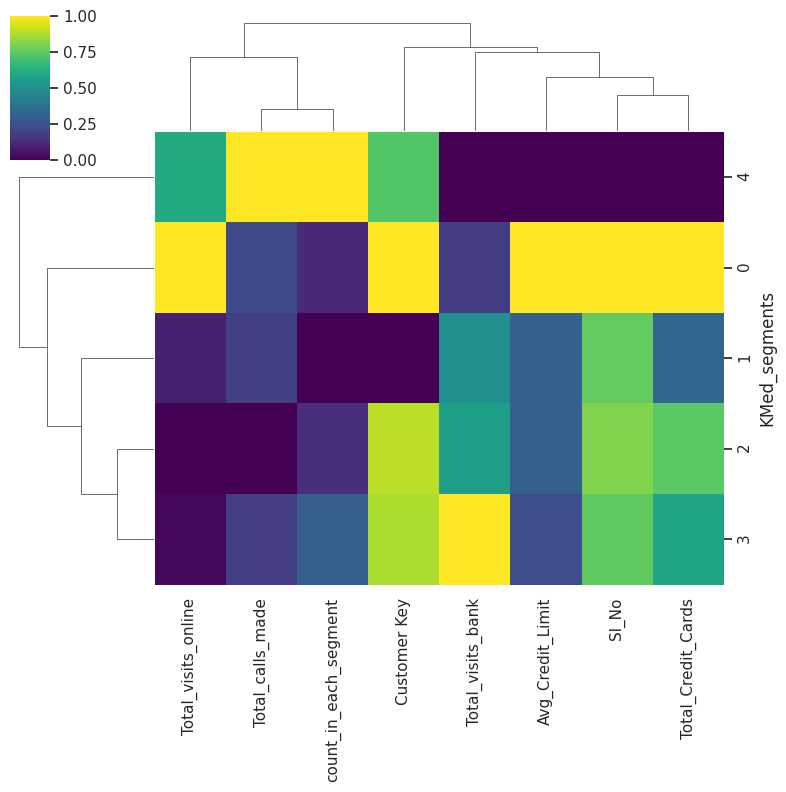

In [ ]:
sns.clustermap(
    kmed_cluster_profile,
    metric="euclidean",
    method="average",
    cmap="viridis",
    standard_scale=1,  # Normalizes data across rows (0 to 1) to make patterns clear
    figsize=(8, 8),
)

# Display the plot
plt.show()

**Looks more evenly spread than K-means.**

**Hierarchical Clustering (agglomerative)**

---



In [ ]:
data_pca.head()

,0,1,2,3
0,0.192043,-0.467997,-1.887658,-0.589809
1,3.078879,1.465291,0.906490,-0.525376
2,0.104195,0.918178,-0.091459,1.019186
3,0.354753,-0.075058,-0.559128,0.797247
4,1.354527,3.221894,0.098265,-0.774539


In [ ]:
hc_df = data_pca.copy()

In [ ]:
hc_df1 = hc_df.copy()

In [ ]:
# List of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# List of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

In [ ]:
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(hc_df1, metric = dm, method = lm)
        c, coph_dists = cophenet(Z, pdist(hc_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

# Printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.6343009131945329.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8286819013781801.
Cophenetic correlation for Euclidean distance and average linkage is 0.8659395410098029.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8394202554026082.
Cophenetic correlation for Chebyshev distance and single linkage is 0.6180039504333141.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8466238324039881.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8656561531524158.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8587573946223289.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.6304507562533583.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.49966705229278924.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.797543094660376.
Cophenetic co

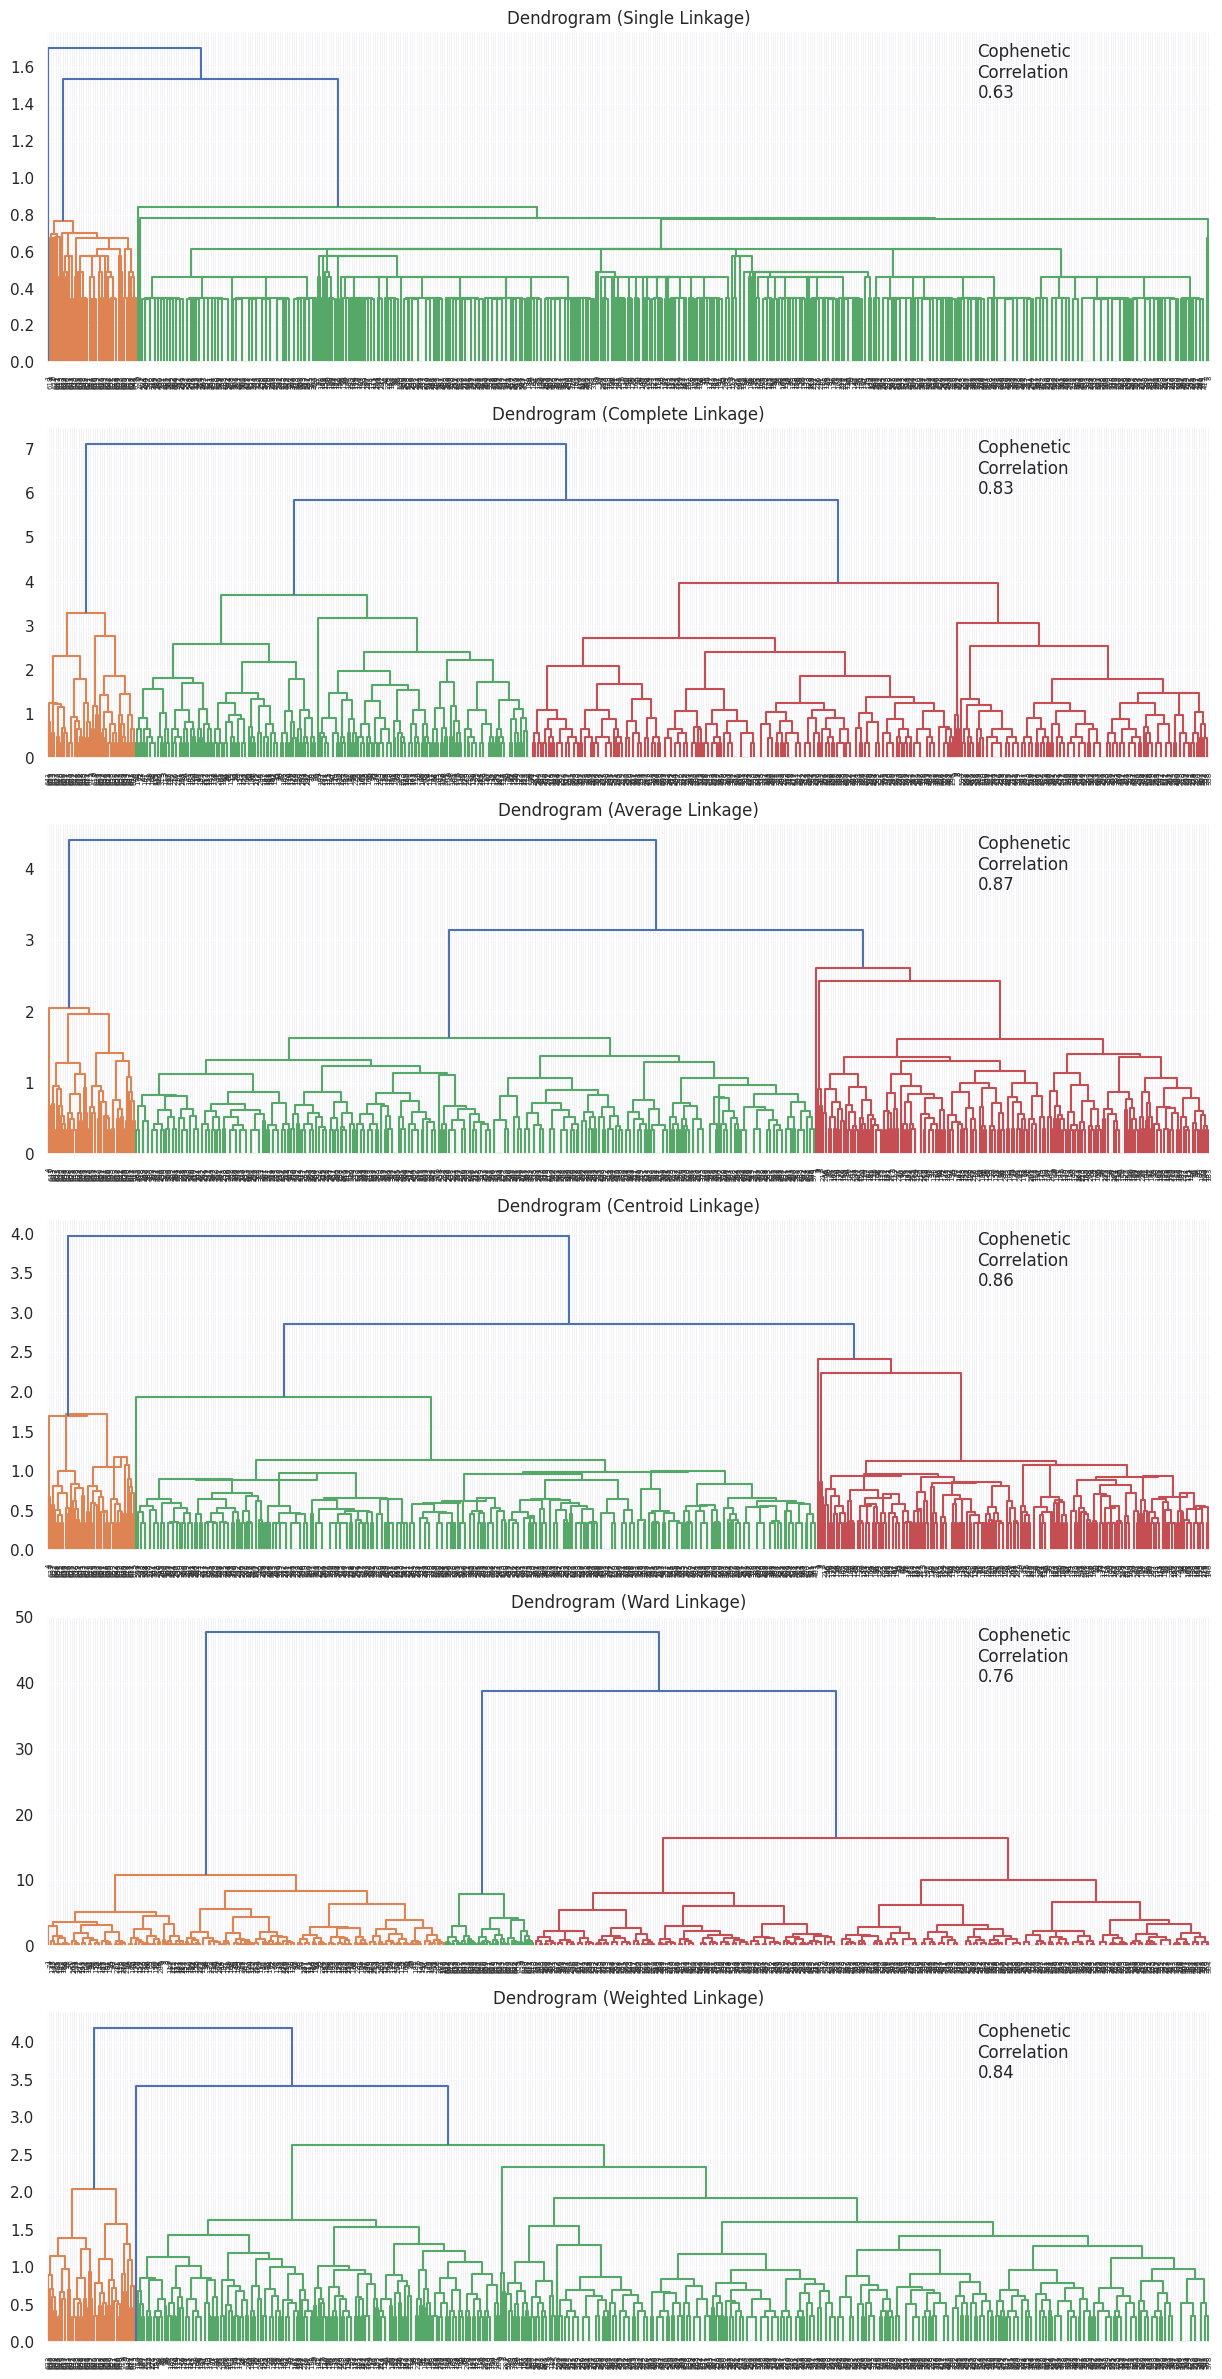

In [ ]:
# List of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# Lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# To create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize = (15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df1, metric = "euclidean", method = method)

    dendrogram(Z, ax = axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

In [ ]:
# Create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc = pd.DataFrame(compare, columns = compare_cols)

df_cc = df_cc.sort_values(by = "Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.634301
4,ward,0.764591
1,complete,0.828682
5,weighted,0.839420
3,centroid,0.862606
2,average,0.865940


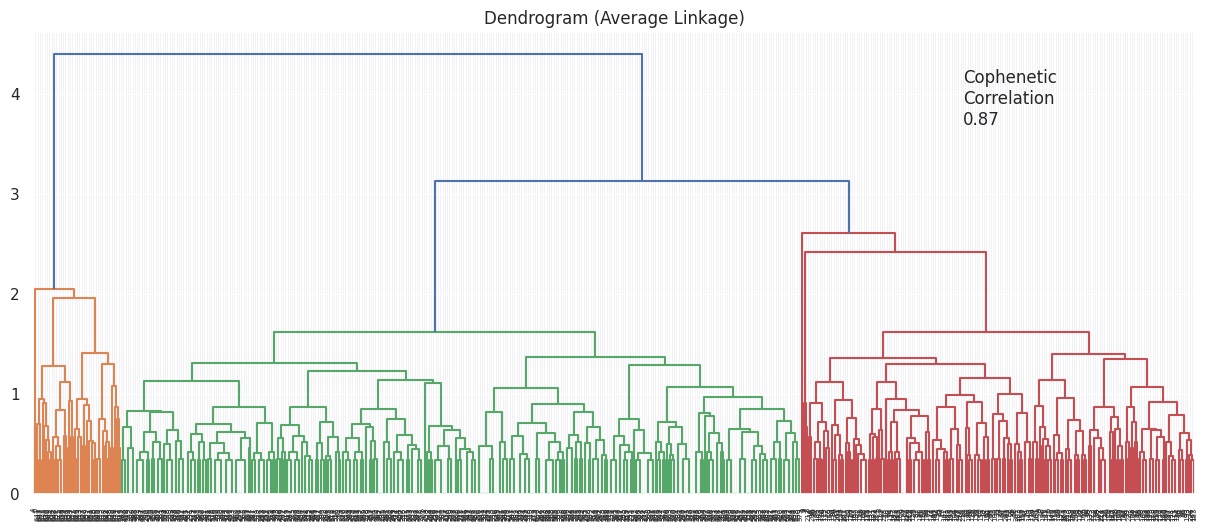

In [ ]:
# Select only the average linkage method
linkage_method = "average"

# Lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# To create a single plot image instead of subplots
fig, ax = plt.subplots(figsize=(15, 6))

# Perform hierarchical clustering using the single selected method
Z = linkage(hc_df1, metric="euclidean", method=linkage_method)

# Plot the single dendrogram
dendrogram(Z, ax=ax)
ax.set_title(f"Dendrogram ({linkage_method.capitalize()} Linkage)")

# Calculate the cophenetic correlation
coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
ax.annotate(
    f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
    (0.80, 0.80),
    xycoords="axes fraction",
)

# Save result to list
compare.append([linkage_method, coph_corr])

**5 clusters, Euclidean distance, average linkage**

In [ ]:
HCmodel = AgglomerativeClustering(n_clusters = 5, metric = "euclidean", linkage = "average")
HCmodel.fit(hc_df1)

AgglomerativeClustering(linkage='average', n_clusters=5)

In [ ]:
# Creating a copy of the original data
df3 = df.copy()

# Adding hierarchical cluster labels to the original and whole dataframes
hc_df["HC_segments_L1"] = HCmodel.labels_
df3["HC_segments_L1"] = HCmodel.labels_

In [ ]:
hc_cluster_profile = df3.groupby("HC_segments_L1").mean(numeric_only = True)

In [ ]:
hc_cluster_profile["count_in_each_segment"] = (
    df3.groupby("HC_segments_L1")["Avg_Credit_Limit"].count().values
)

In [ ]:
hc_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
HC_segments_L1,,,,,,,,
0,611.280000,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50
1,118.309091,55142.813636,12109.090909,2.404545,0.936364,3.540909,6.922727,220
2,418.440415,54873.427461,33505.181347,5.518135,3.494819,0.989637,2.010363,386
3,2.000000,38414.000000,50000.000000,3.000000,0.000000,10.000000,9.000000,1
4,6.000000,68979.666667,40000.000000,2.333333,0.333333,1.333333,1.000000,3


In [ ]:
df3.groupby(["HC_segments_L1", "Total_visits_online"])['Total_Credit_Cards'].count()

HC_segments_L1  Total_visits_online
0               6                        1
                7                        7
                8                        6
                9                        4
                10                       5
                11                       5
                12                       6
                13                       5
                14                       1
                15                      10
1               1                        3
                2                       52
                3                       42
                4                       69
                5                       54
2               0                      144
                1                      104
                2                      136
                3                        2
3               10                       1
4               1                        2
                2                        1
Name: Total_Credit_Cards, dtype: int64

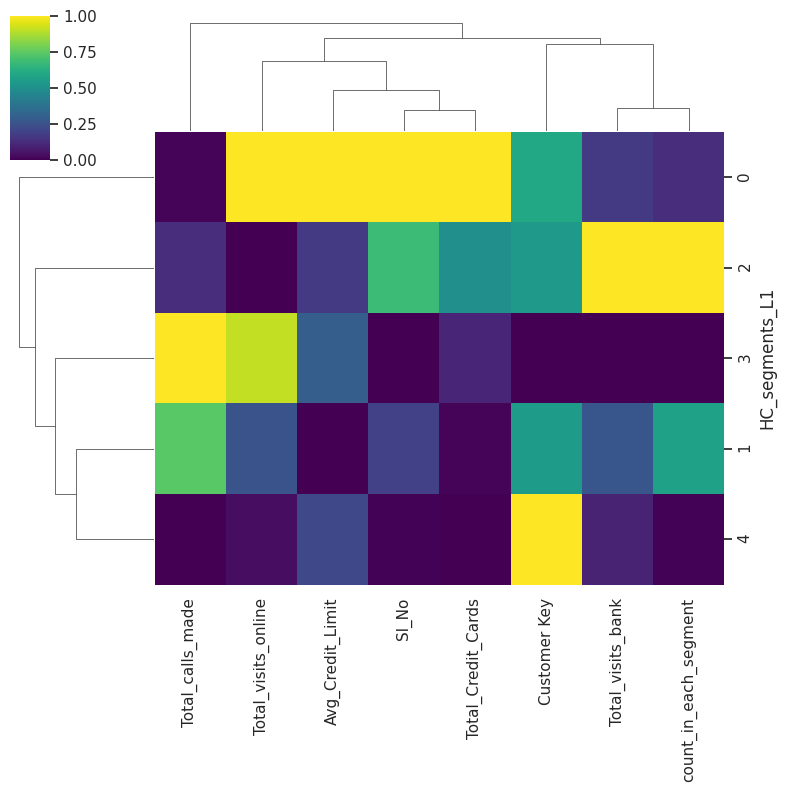

In [ ]:
sns.clustermap(
    hc_cluster_profile,
    metric="euclidean",
    method="average",
    cmap="viridis",
    standard_scale=1,  # Normalizes data across rows (0 to 1) to make patterns clear
    figsize=(8, 8),
)

# Display the plot
plt.show()

**Cluster 0**

*   extremely high visits online
*   high average credit limit
*   high total credit cards
*   low visits to the bank/even lower calls made

▶*DIGITAL FIRST/SELF-SERVICE USERS*

**target**: mobile app updates, improve web-user interface

note: Customer Key (medium range-green)



**Cluster 1**


*   second highest count of customers/second largest group
*   low average credit limit
*   low total number of credit cards
*   significantly higher calls made than visits online/to the bank

▶*SECOND LARGEST SEGMENT*

**target** phone customer service & set up online banking logins to increase #of credit cards/avg. credit limit

note: Customer Key (medium range-green)



**Cluster 2**

*   highest count of customers/largest group
*   extremely high visits to the bank
*   low frequency of calls, even lower visits online

▶*LARGEST SEGMENT OF USERS*

**target:** with both average credit limit & total number of credit cards in a "low-middle" blue/teal range, push to increase avg. credit limit and total  number of credit cards by improving customer service (via calls or online) to reduce the unusually high walk ins to the bank

note: Customer Key (medium range-green)



**Cluster 3**
*   low count of customers/smaller group
*   low customer keys
*   low visits to the bank
*   extremely high/highest number of calls made followed by medium/high online visits
*   low number of credit cards with slighlty higher average credit limit

▶*THE PHONE CALLERS*

**target:** create a promotional offer via phone/online for this small segment of customers| their slightly higher average credit limit shows responsible use and they should be incentivized to add another credit card or work towards higher credit limits through a structured offer

note: Customer Key (lowest range-dark blue)
*based on a logical guess that the lower customer keys could indicate the oldest/earliest enrolled customers, one could infer that phone service predated the bank's expansion to digital customer service*



**Cluster 4** low count of customers/smaller group, highest customer keys, very low number of calls made with slightly more, but low, visits online and slightly more, but low, visits to the bank

▶*THE LATEST OR THE ODDEST*

**target:** these could be outliers in the whole dataset due to unusually low banking behavior across all columns, or, based on a logical guess that the high customer keys could indicate the latest/newest, enrolled customers, they could be the smaller segment of poorly engaged customers leading the bank to seek help in the first place

note: Customer key (highest range-yellow)

$\color{red}{\text{In a re-iteration of this project, might have wanted to REMOVE
SI_ID, serial numbers, at least, if not also CUSTOMER KEYS to prevent possible/likely distortions of the prior distance-based models: K-means, K-medioids, and hierarchical clustering, though they seem to have been functional with customer keys so far and justified keeping them to test out the initial intuition of possibly sequentially/temporally meaningful customer keys for the business problem at hand.}}$

**Gausian Mixture Model (GMM) Clustering | Probability-based rather than Distance:**

In [ ]:
gmm_df = data_pca.copy()

In [ ]:
# Let's apply Gaussian Mixture
gmm = GaussianMixture(n_components = 5, random_state = 1)  # Initializing the Gaussian Mixture algorithm with n_components = 5

gmm.fit(gmm_df)                                            # Fitting the algorithm on the gmm_df data

GaussianMixture(n_components=5, random_state=1)

In [ ]:
# Creating a copy of the original data
df4 = df.copy()

# Adding GMM cluster labels to the original and scaled dataframes
gmm_df["GMM_segments"] = gmm.predict(gmm_df)
df4["GMM_segments"] = gmm.predict(data_pca)

In [ ]:
gmm_cluster_profile = df4.groupby("GMM_segments").mean(numeric_only = True)

In [ ]:
gmm_cluster_profile["count_in_each_segment"] = (
    df4.groupby("GMM_segments")["Total_Credit_Cards"].count().values
)


In [ ]:
#the most even distribution of counts in segments seen so far
gmm_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
GMM_segments,,,,,,,,
0,419.091371,54165.274112,36111.675127,5.543147,2.492386,0.959391,2.071066,197
1,121.278846,56691.576923,12567.307692,2.192308,0.884615,3.653846,8.653846,104
2,113.218487,53828.924370,11873.949580,2.588235,0.966387,3.478992,5.336134,119
3,415.363158,55714.684211,31226.315789,5.478947,4.515789,1.010526,1.936842,190
4,611.280000,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50


In [ ]:
df4.groupby(["GMM_segments", "Total_visits_online"])['Avg_Credit_Limit'].count()

GMM_segments  Total_visits_online
0             0                      72
              1                      62
              2                      62
              3                       1
1             1                       1
              2                      23
              3                      20
              4                      32
              5                      27
              10                      1
2             1                       2
              2                      30
              3                      23
              4                      37
              5                      27
3             0                      72
              1                      44
              2                      74
4             6                       1
              7                       7
              8                       6
              9                       4
              10                      5
              11                      5
              12                      6
              13                      5
              14                      1
              15                     10
Name: Avg_Credit_Limit, dtype: int64

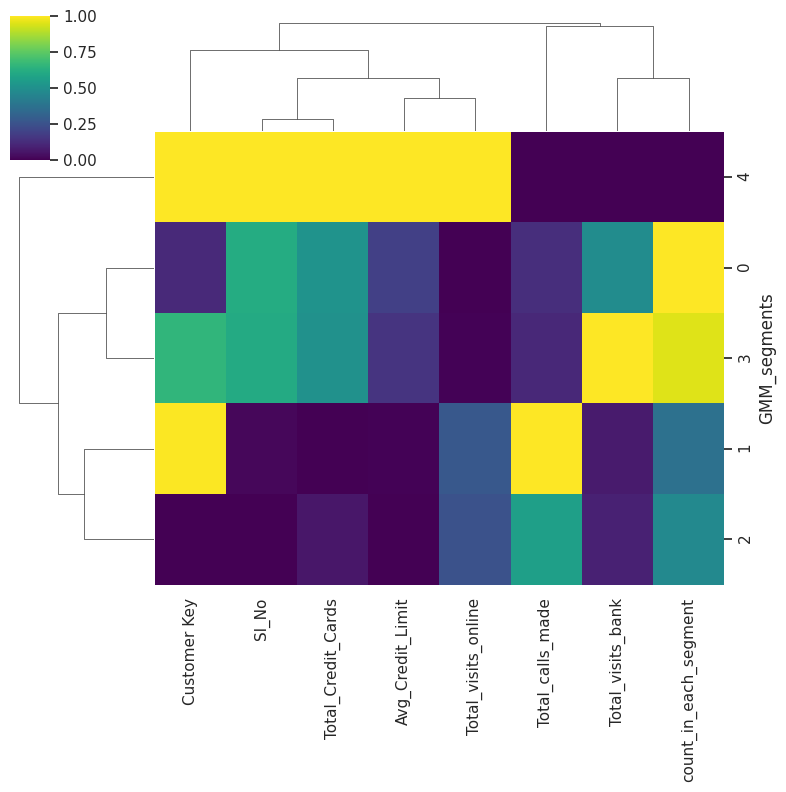

In [ ]:
sns.clustermap(
    gmm_cluster_profile,
    metric="euclidean",
    method="average",
    cmap="viridis",
    standard_scale=1,  # Normalizes data across rows (0 to 1) to make patterns clear
    figsize=(8, 8),
)

# Display the plot
plt.show()

**Cluster 4**
▶*DIGITAL FIRST/SELF-SERVICE USERS*

*   Highest total credit cards, highest average credit limits, highest total visits online
*   count: 50


**Cluster 1**
▶*THE PHONE CALLERS*
*   Highest total calls made
*   count: 112


**Cluster 2**
▶*THE ODDEST*
*   Least engaged, low total credit cards and average credit limits, more phone calls made
* count: 119


**Cluster 0**
▶*LARGEST SEGMENT, BANK VISITORS*
*   high bank visits and more credit cards than average credit limit
*   count: 197


**Cluster 3**
▶*SECOND LARGEST SEGMENT*
*   high bank visits and more credit cards than average credit limit
*   count: 190






**DBSCAN (Density-Based Spatial Clustering of Algorithms with Noise)**

In [ ]:
dbscan_df = data_pca.copy()
dbscan_df1 = dbscan_df.copy()

In [ ]:
# Initializing lists
eps_value = [0.3, 0.5, 0.7, 1.0, 1.5]  #since data already scaled
min_sample_values = [3, 10]


# Creating a dictionary for each of the values in eps_value with min_sample_values
res = {eps_value[i]: min_sample_values for i in range(len(eps_value))}

In [ ]:
import numpy as np
# Finding the silhouette_score for each of the combination
from sklearn.preprocessing import StandardScaler

# Scale the data first
scaler = StandardScaler()
dbscan_df_scaled = scaler.fit_transform(dbscan_df)


high_silhouette_avg = 0                                               # Assigning 0 to the high_silhouette_avg variable
high_i_j = [0, 0]                                                     # Assigning 0's to the high_i_j list
key = res.keys()                                                      # Assigning dictionary keys to a variable called key
for i in key:
    z = res[i]                                                        # Assigning dictionary values of each i to z
    for j in z:
        db = DBSCAN(eps = i, min_samples = j).fit(dbscan_df)          # Applying DBSCAN to each of the combinations in dictionary
        core_samples_mask = np.zeros_like(db.labels_, dtype = bool)
        core_samples_mask[db.core_sample_indices_] = True
        labels = db.labels_

        # Check the number of unique labels (clusters), excluding noise (-1)
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters_ < 2:
            silhouette_avg = -1 # Assign a value indicating an invalid silhouette score
            print(
                "For eps value =" + str(i),
                "For min sample =" + str(j),
                "Number of clusters found is less than 2. Cannot compute silhouette score.",
            )
        else:
            silhouette_avg = silhouette_score(dbscan_df, labels)          # Finding silhouette score
            print(
                "For eps value =" + str(i),
                "For min sample =" + str(j),
                "The average silhoutte_score is :",
                silhouette_avg,                                          # Printing the silhouette score for each of the combination
            )

        if high_silhouette_avg < silhouette_avg:                     # If the silhouette score is greater than 0 or the previous score, it will get appended to the high_silhouette_avg list with its combination of i and j
            high_i_j[0] = i
            high_i_j[1] = j

For eps value =0.3 For min sample =3 The average silhoutte_score is : -0.11551398767965983
For eps value =0.3 For min sample =10 Number of clusters found is less than 2. Cannot compute silhouette score.
For eps value =0.5 For min sample =3 The average silhoutte_score is : -0.003347045164749283
For eps value =0.5 For min sample =10 The average silhoutte_score is : -0.021078566366557715
For eps value =0.7 For min sample =3 The average silhoutte_score is : 0.23487118090446604
For eps value =0.7 For min sample =10 Number of clusters found is less than 2. Cannot compute silhouette score.
For eps value =1.0 For min sample =3 The average silhoutte_score is : 0.35844675300653067
For eps value =1.0 For min sample =10 The average silhoutte_score is : 0.4493750620638052
For eps value =1.5 For min sample =3 The average silhoutte_score is : 0.35844675300653067
For eps value =1.5 For min sample =10 The average silhoutte_score is : 0.35844675300653067


Highest avg silhouette score is at sample=10, eps value=1.5 at 0.35844675300653067

In [ ]:
# Applying DBSCAN with eps as 1.5 and min sample as 10
dbs = DBSCAN(eps = 1.5, min_samples = 10)

In [ ]:
# Creating a copy of the original data
df5 = df.copy()

# Add DBSCAN cluster labels to dbscan data
dbscan_df1["db_segments"] = dbs.fit_predict(dbscan_df1)

# Add DBSCAN cluster labels to whole data
df5["db_segments"] =  dbs.fit_predict(dbscan_df)

In [ ]:
db_cluster_profile = df5.groupby("db_segments").mean(numeric_only = True)

In [ ]:
db_cluster_profile["count_in_each_segment"] = (
    df5.groupby("db_segments")["Total_Credit_Cards"].count().values
)

In [ ]:
#odd to see that one outlier point, the StandardScaler applied initially may not have been apporpriate for DBSCAN

db_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
db_segments,,,,,,,,
-1,2.000000,38414.000000,50000.000000,3.000000,0.000000,10.000000,9.000000,1
0,307.986864,55040.231527,25807.881773,4.377668,2.555008,1.912972,3.779967,609
1,611.280000,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50


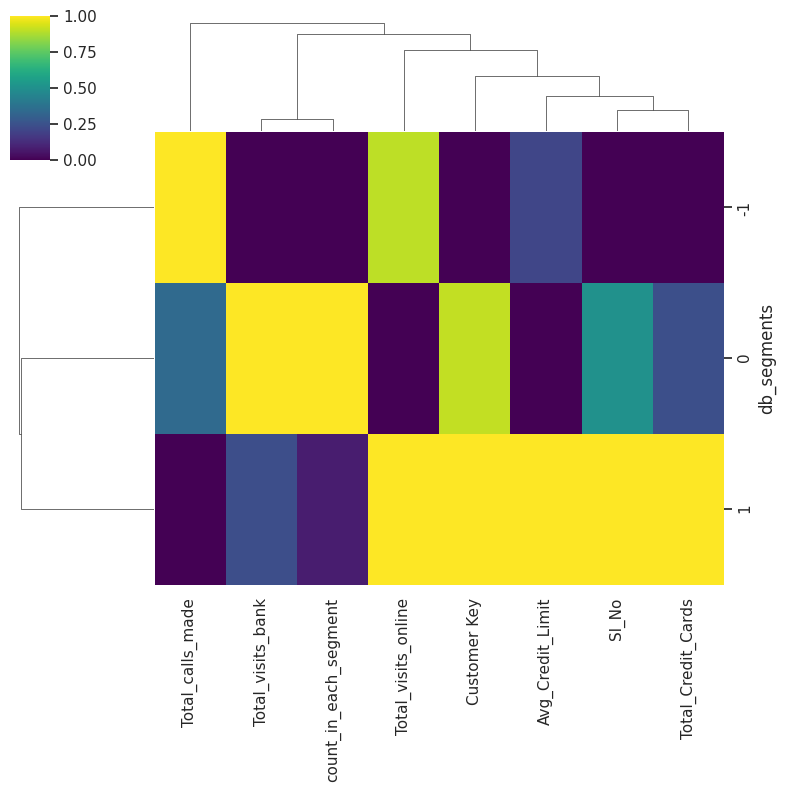

In [ ]:
sns.clustermap(
    db_cluster_profile,
    metric="euclidean",
    method="average",
    cmap="viridis",
    standard_scale=1,  # Normalizes data across rows (0 to 1) to make patterns clear
    figsize=(8, 8),
)

# Display the plot
plt.show()

This model doesn't seem to suit this particular dataset, not only due to scaling but also the dataset is relatively uniform and lacks major density peaks to capture with DBSCAN.

**Choosing the best algorithm**



In [ ]:
kmeans = KMeans(n_clusters = 4, random_state = 1, n_init = 'auto')        # Initializing K-Means with number of clusters as 4 and random_state=1

preds = kmeans.fit_predict((data_pca))                   # Fitting and predicting K-Means on data_pca

score = silhouette_score(data_pca, preds)                # Calculating the silhouette score

print(score)

0.4091566381112921


In [ ]:
kmedoids = KMedoids(n_clusters = 4, random_state = 1)   # Initializing K-Medoids with number of clusters as 4 and random_state=1

preds = kmedoids.fit_predict((data_pca))                # Fitting and predicting K-Medoids on data_pca

score = silhouette_score(data_pca, preds)               # Calculating the silhouette score

print(score)

0.25701362865700567


In [ ]:
# Initializing Agglomerative Clustering with distance as Euclidean, linkage as ward with clusters = 4
HCmodel = AgglomerativeClustering(n_clusters = 4, metric = "euclidean", linkage = "ward",)

# Fitting on PCA data
preds = HCmodel.fit_predict(data_pca)

score = silhouette_score(data_pca, preds)             # Calculating the silhouette score

print(score)

0.37065627066983825


In [ ]:
# Initializing Gaussian Mixture algorithm with number of clusters as 4 and random_state = 1
gmm = GaussianMixture(n_components=4, random_state=1)

# Fitting and predicting Gaussian Mixture algorithm on data_pca
preds = gmm.fit_predict((data_pca))

# Calculating the silhouette score
score = silhouette_score(data_pca, preds)

# Printing the score
print(score)

0.4107857255392117


**Gaussian**👍 Not only does Gaussian have the ideal silhouette score among the models, it is also not distance-based and best given the inclusion of customer keys in the dataset.

# **Conclusion:**

*   GMM clusters appear to resemble the hierarchical agglomerative clustering model's clusters built through avereage linkage, Euclidean distance
*   Need to consider dropping serial numbers (at least) and possibly customer keys in re-modeling the dataset

# **Recommendations:**

**G M M   C L U S T E R S**

To reach **new customers:** run a promotion for existing customers (since the largest segments [Cluster 0, 3] visit the bank in-person) to benefit through referrals for new customers  

**Cluster 4**
$\color{#1E90FF}{\text{▶DIGITAL FIRST/SELF-SERVICE USERS}}$

*   Highest total credit cards, highest average credit limits, highest total visits online
*   count: 50

▶▶**target**: mobile app updates, improve web-user interface, create effective surveys

note: Cluster 0 of HCmodel


---


**Cluster 1**
$\color{#1E90FF}{\text{▶THE PHONE CALLERS}}$
*   Highest total calls made, lowest total number of credit cards, lowest average credit limits
*   count: 104

▶▶**target** these could be the most unhappy, existing customers - improve phone customer service & guide to set up online banking logins to match the profiles of Cluster 4, where increased online banking is correlated with an increase #of credit cards/avg. credit limit, offer "desperate" promotions to increase total credit cards

note: Cluster 3 of HCmodel


---


**Cluster 2**
$\color{#1E90FF}{\text{▶THE ODDEST}}$
*   Least engaged, low total credit cards and lower average credit limits, more phone calls made
* count: 119

▶▶**target:** these could be outliers (and most inactive customers) in the whole dataset due to unusually low banking behavior across all columns and higher attempts to call customer service - pivot customers from phone calls to online banking and increase engagement by offering guided opportunites to expand credit limits with current credit cards, as there is a slightly greater number of total credit cards in this group than average credit limits

note: Cluster 4 of HCmodel



---



**Cluster 0**
$\color{#1E90FF}{\text{▶LARGEST SEGMENT, BANK VISITORS}}$
*   high bank visits and more credit cards than average credit limit
*   count: 197

▶▶**target:** with both average credit limit & total number of credit cards in a "low-middle" blue/teal range, push to increase avg. credit limit and total  number of credit cards by improving customer service (via calls or online) to reduce the unusually high walk ins to the bank, or leverage walk ins to the bank with appropriate face-to-face marketing tactics to set up online profiles and bring number of credit cards/avg credit limits to a medium-to-high range, modeled after Cluster 4


note: Cluster 2 of HCmodel



---



**Cluster 3**
$\color{#1E90FF}{\text{▶SECOND LARGEST SEGMENT, BANK VISITORS}}$
*   high bank visits and more credit cards than average credit limit
*   count: 190

▶▶**target:** total credit cards appears higher than the average credit limit, so the in-person bank visits could focus on expanding the current credit cards' credit limits through responsible financial planning and advising, offers to earn access to more credit cards, and set up online banking


note: Cluster 1 of HCmodel




---


